<a href="https://colab.research.google.com/github/de-fernandez/CPE-313-CPE32S3/blob/main/Group%2010%2C%20CPE32S3%2C%20CPE%20313%20(Assignment%205.1%20-%20Time-Series%20Stationarity%20Diagnostics%20%26%20Forecasting%20Techniques).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Part 1

A1

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_pacf, plot_acf
from scipy import stats

In [3]:
ts = pd.read_csv("/content/drive/MyDrive/CPE313/Activity 5.1/dataset/train.csv")
ts = pd.DataFrame(ts)
ts.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


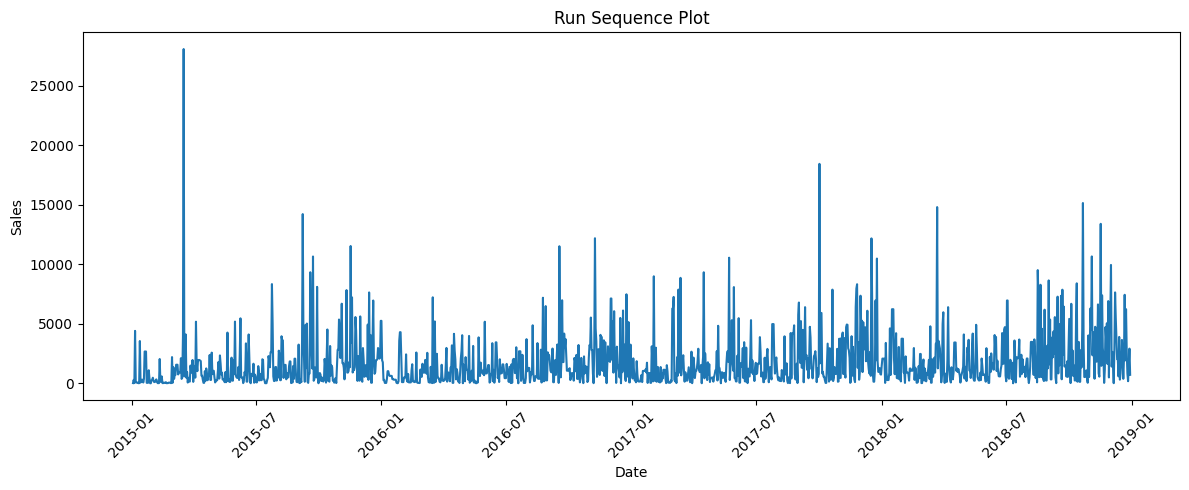

In [4]:
ts["Order Date"] = pd.to_datetime(ts["Order Date"], dayfirst=True)
ts = ts.groupby("Order Date")["Sales"].sum()
ts = ts.sort_index()

ts = ts.asfreq("D").ffill()

plt.figure(figsize=(12,5))
plt.plot(ts)
plt.title("Run Sequence Plot")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

A2

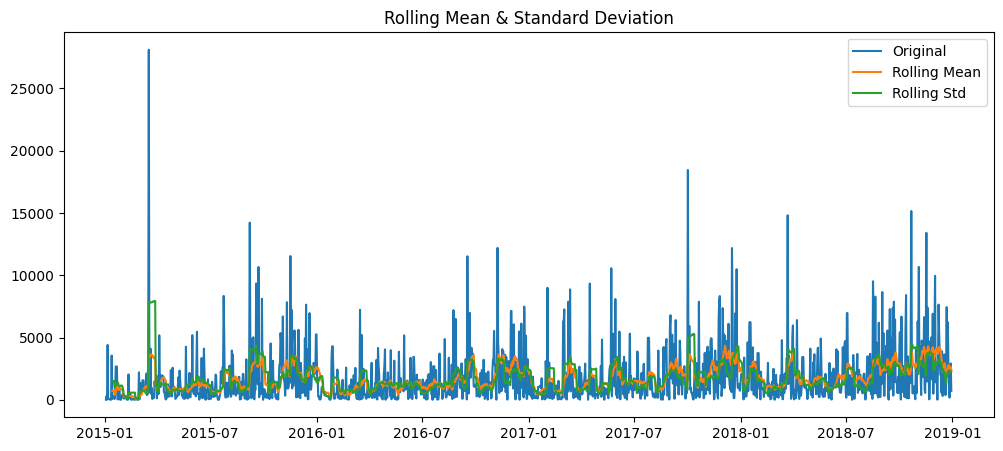

In [5]:
rolling_mean = ts.rolling(window=12).mean()
rolling_std = ts.rolling(window=12).std()

plt.figure(figsize=(12,5))
plt.plot(ts, label="Original")
plt.plot(rolling_mean, label="Rolling Mean")
plt.plot(rolling_std, label="Rolling Std")
plt.legend()
plt.title("Rolling Mean & Standard Deviation")
plt.show()

A3

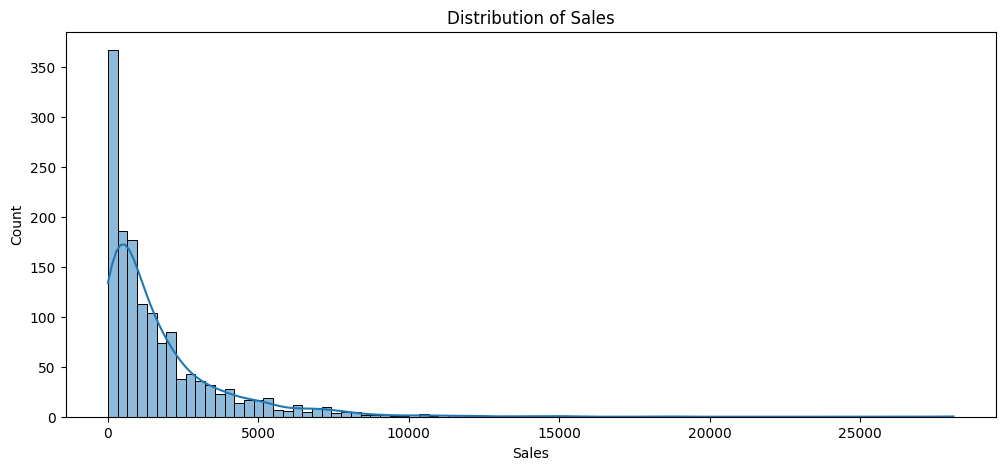

In [6]:
plt.figure(figsize=(12,5))
sns.histplot(ts, kde=True)
plt.title("Distribution of Sales")
plt.show()

A4

In [7]:
result = adfuller(ts)

print("ADF Statistic:", result[0])
print("p-value:", result[1])
print("Critical Values:")

for key, value in result[4].items():
    print(f"{key}: {value}")

ADF Statistic: -6.251366350804214
p-value: 4.4457704265947836e-08
Critical Values:
1%: -3.4348929812602784
5%: -2.863546418485167
10%: -2.5678382024888378


A5

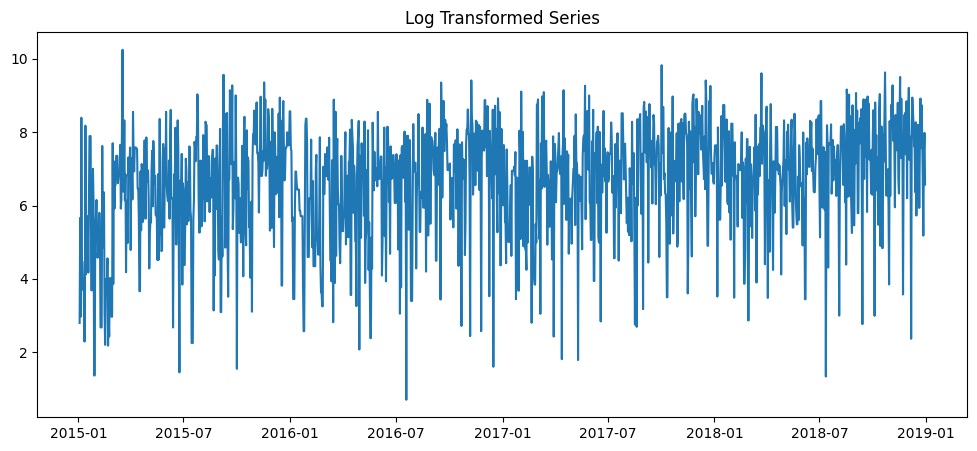

In [8]:
ts_log = np.log(ts)

plt.figure(figsize=(12,5))
plt.plot(ts_log)
plt.title("Log Transformed Series")
plt.show()

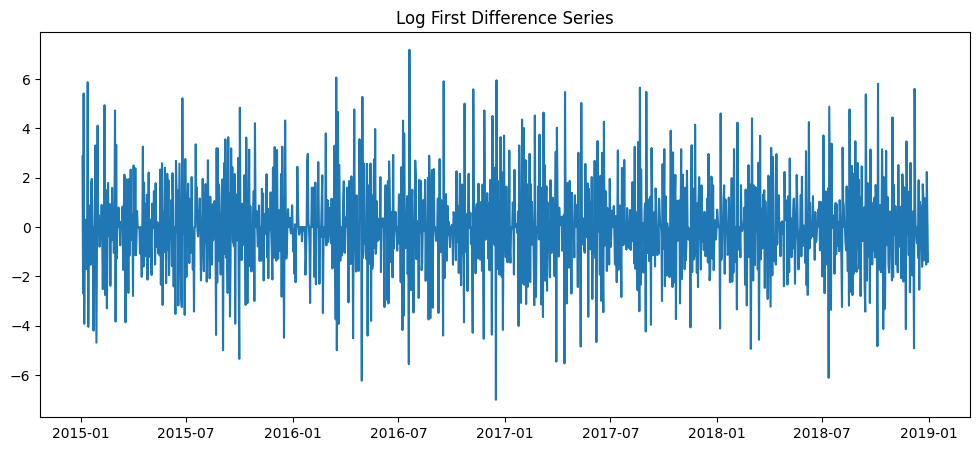

In [9]:
ts_diff = ts_log.diff()

plt.figure(figsize=(12,5))
plt.plot(ts_diff)
plt.title("Log First Difference Series")
plt.show()

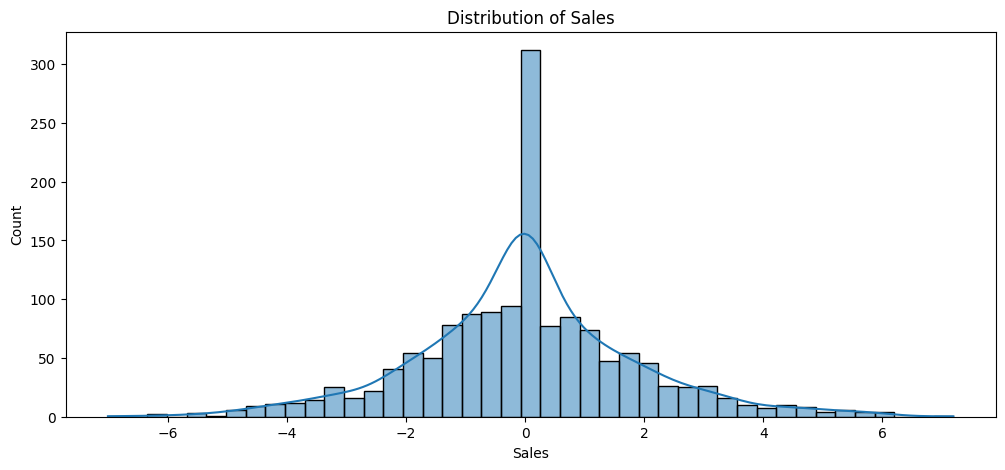

In [10]:
plt.figure(figsize=(12,5))
sns.histplot(ts_diff, kde=True)
plt.title("Distribution of Sales")
plt.show()

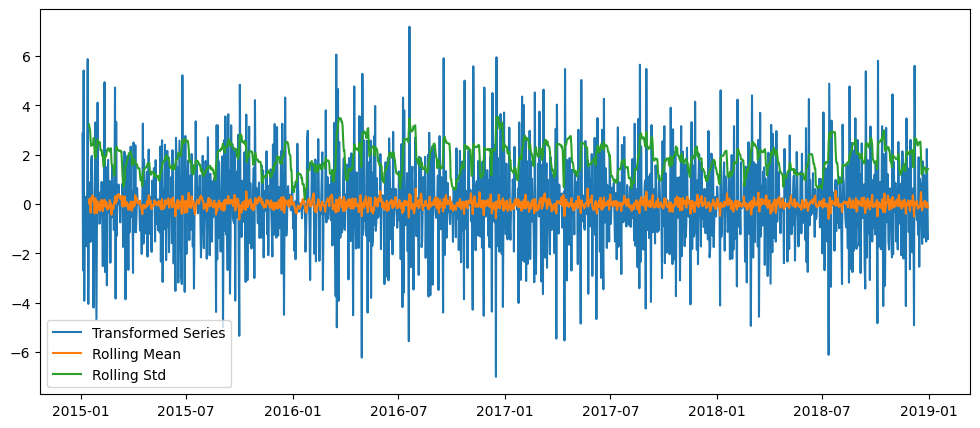

In [11]:
rolling_mean2 = ts_diff.rolling(12).mean()
rolling_std2 = ts_diff.rolling(12).std()

plt.figure(figsize=(12,5))
plt.plot(ts_diff, label="Transformed Series")
plt.plot(rolling_mean2, label="Rolling Mean")
plt.plot(rolling_std2, label="Rolling Std")
plt.legend()
plt.show()


# Part 2

1. Hold-out split – last 20 % of observations → test set.

In [12]:
split = int(len(ts) * 0.8)

train = ts[:split]
test = ts[split:]

print(len(train), len(test))

1166 292


Model 1: Smoothing (Simple Moving Average with Grid Search)

In [13]:
windows = [3,5,7,10,12,15,20]

best_window = None
best_mse = float("inf")

for w in windows:

    preds = []

    for i in range(len(test)):
        history = pd.concat([train, test[:i]])
        preds.append(history.tail(w).mean())

    mse = mean_squared_error(test, preds)

    if mse < best_mse:
        best_mse = mse
        best_window = w

print("Best window:", best_window)

Best window: 15


In [14]:
sma_preds = []

for i in range(len(test)):
    history = pd.concat([train, test[:i]])
    sma_preds.append(history.tail(best_window).mean())

sma_preds = np.array(sma_preds)

Model 2: Autoregression (AR-p) – choose p via PACF or AIC minimisation.

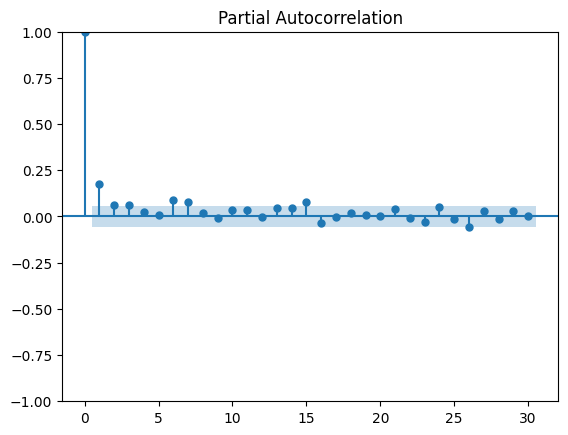

In [15]:
plot_pacf(train, lags=30)
plt.show()

In [16]:
p = 0


ar_model = AutoReg(train, lags=p).fit()

ar_preds = ar_model.predict(
    start=len(train),
    end=len(train)+len(test)-1,
    dynamic=False
)

Model 3: ARIMA(p,d,q) – use auto_arima (or manual grid search) on the stationary series.

In [17]:
arima_model = ARIMA(train, order=(5,1,2)).fit()

arima_preds = arima_model.forecast(steps=len(test))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


In [18]:
def MAPE(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred)/y_true))*100


results = pd.DataFrame({
    "Model": ["SMA", "AR", "ARIMA"],
    "MSE": [
        mean_squared_error(test, sma_preds),
        mean_squared_error(test, ar_preds),
        mean_squared_error(test, arima_preds)
    ],
    "MAPE": [
        MAPE(test, sma_preds),
        MAPE(test, ar_preds),
        MAPE(test, arima_preds)
    ]
})

print(results)

   Model           MSE        MAPE
0    SMA  5.955215e+06  801.366504
1     AR  6.674649e+06  532.829431
2  ARIMA  6.770466e+06  516.549236


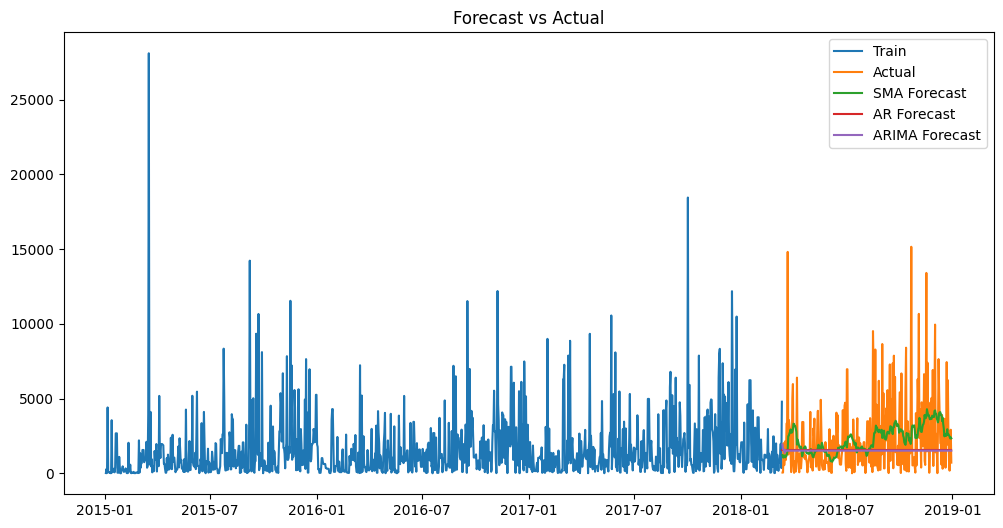

In [19]:
plt.figure(figsize=(12,6))

plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Actual")

plt.plot(test.index, sma_preds, label="SMA Forecast")
plt.plot(test.index, ar_preds, label="AR Forecast")
plt.plot(test.index, arima_preds, label="ARIMA Forecast")

plt.legend()
plt.title("Forecast vs Actual")
plt.show()

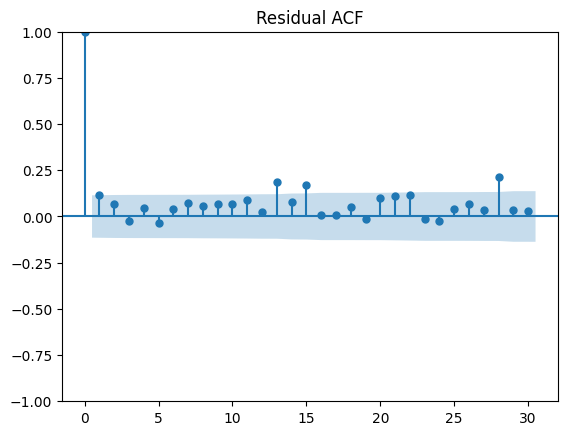

In [20]:
residuals = test - arima_preds

plot_acf(residuals, lags=30)
plt.title("Residual ACF")
plt.show()